# Predictive-Edge: Uç Birim Kestirimci Bakım Modülü

> **TÜBİTAK BiGG 1812 — Teknik Prototip (PoC)**  
> Yüksek devirli endüstriyel motorlarda (CNC / Pompa) sensör verilerinden
> yapay sinir ağı ile arıza tespiti.

---

| Modül | İçerik |
|-------|--------|
| 1 | Sentetik veri üretimi ve fiziksel simülasyon |
| 2 | Sinyal işleme ve özellik çıkarımı (RMS, FFT) |
| 3 | YSA (MLP) tasarımı, eğitimi ve değerlendirmesi |
| 4 | Dashboard çıktısı ve görselleştirme |


In [1]:
# ── Kütüphane kurulumu (ilk çalıştırmada gerekirse) ─────────────────────────
# !pip install numpy pandas scipy scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import scipy.fft as spfft
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


---
## Modül 1 — Sentetik Veri Üretimi ve Fiziksel Simülasyon

In [2]:
# ── Sinyal parametreleri ─────────────────────────────────────────────────────
SAMPLE_RATE   = 1000   # Hz — örnekleme frekansı
DURATION      = 1.0    # saniye — her örnek penceresi
N_POINTS      = int(SAMPLE_RATE * DURATION)  # 1000 noktalı sinyal
N_HEALTHY     = 500
N_FAULTY      = 500
t = np.linspace(0, DURATION, N_POINTS, endpoint=False)  # zaman ekseni


def generate_healthy_signal():
    """Sağlıklı motor: 50 Hz temel sinüs + düşük Gauss gürültüsü."""
    vibration = 1.0 * np.sin(2 * np.pi * 50 * t) + np.random.normal(0, 0.05, N_POINTS)
    temperature = np.random.normal(loc=38.5, scale=1.5)   # 35–42 °C
    current     = np.random.uniform(4.8, 5.2)             # 4.8–5.2 A
    return vibration, temperature, current


def generate_faulty_signal():
    """Arızalı motor: temel + 2. & 3. harmonikler + yüksek gürültü."""
    base      = 1.0  * np.sin(2 * np.pi * 50  * t)
    harmonic2 = 0.45 * np.sin(2 * np.pi * 100 * t)  # 2. harmonik
    harmonic3 = 0.25 * np.sin(2 * np.pi * 150 * t)  # 3. harmonik
    noise     = np.random.normal(0, 0.3, N_POINTS)
    vibration = base + harmonic2 + harmonic3 + noise
    temperature = np.random.uniform(65, 85)            # 65–85 °C
    current     = np.random.uniform(7.5, 10.0)         # 7.5–10.0 A
    return vibration, temperature, current


# ── 1000 örnek üret ─────────────────────────────────────────────────────────
records = []

for _ in range(N_HEALTHY):
    vib, temp, cur = generate_healthy_signal()
    records.append({'signal': vib, 'temperature': temp, 'current': cur, 'label': 0})

for _ in range(N_FAULTY):
    vib, temp, cur = generate_faulty_signal()
    records.append({'signal': vib, 'temperature': temp, 'current': cur, 'label': 1})

raw_df = pd.DataFrame(records)
raw_df = raw_df.sample(frac=1, random_state=42).reset_index(drop=True)  # karıştır

print(f'Toplam örnek sayısı : {len(raw_df)}')
print(f'Sağlıklı (0)        : {(raw_df.label == 0).sum()}')
print(f'Arızalı  (1)        : {(raw_df.label == 1).sum()}')

Toplam örnek sayısı : 1000
Sağlıklı (0)        : 500
Arızalı  (1)        : 500


---
## Modül 2 — Sinyal İşleme ve Özellik Çıkarımı

In [3]:
def compute_rms(signal: np.ndarray) -> float:
    """Titreşim RMS: sqrt(1/N * sum(x_n^2))"""
    return float(np.sqrt(np.mean(signal ** 2)))


def compute_peak_to_peak(signal: np.ndarray) -> float:
    return float(signal.max() - signal.min())


def compute_mean(signal: np.ndarray) -> float:
    return float(np.mean(np.abs(signal)))


def compute_fft_features(signal: np.ndarray, sample_rate: int = SAMPLE_RATE):
    """
    FFT uygula → baskın frekans ve spektral enerji yoğunluğu döndür.
    X(k) = sum_{n=0}^{N-1} x(n) * e^{-j2π nk/N}
    """
    N = len(signal)
    freq_bins = spfft.rfftfreq(N, d=1.0 / sample_rate)       # frekans ekseni
    fft_magnitude = np.abs(spfft.rfft(signal)) / N            # normalize büyüklük

    dominant_freq = float(freq_bins[np.argmax(fft_magnitude[1:]) + 1])  # DC'yi atla
    spectral_energy = float(np.sum(fft_magnitude ** 2))                 # Parseval
    return dominant_freq, spectral_energy


# ── Tüm örnekler için özellik çıkar ─────────────────────────────────────────
feature_rows = []
for _, row in raw_df.iterrows():
    sig = row['signal']
    dom_freq, spec_energy = compute_fft_features(sig)
    feature_rows.append({
        'vibration_rms'   : compute_rms(sig),
        'peak_to_peak'    : compute_peak_to_peak(sig),
        'mean_abs'        : compute_mean(sig),
        'dominant_freq_hz': dom_freq,
        'spectral_energy' : spec_energy,
        'temperature'     : row['temperature'],
        'current_a'       : row['current'],
        'label'           : row['label'],
    })

feat_df = pd.DataFrame(feature_rows)
print('Özellik matrisi boyutu:', feat_df.shape)
feat_df.head(3)

Özellik matrisi boyutu: (1000, 8)


,vibration_rms,peak_to_peak,mean_abs,dominant_freq_hz,spectral_energy,temperature,current_a,label
0,0.844673,3.774612,0.713291,50.0,0.356795,74.922485,9.058069,1
1,0.851365,4.101012,0.713220,50.0,0.362600,83.321913,8.482647,1
2,0.835125,4.085080,0.705562,50.0,0.348757,74.620811,8.141671,1


In [4]:
# ── Sınıf başına istatistiksel özet ─────────────────────────────────────────
print('=== SINIF İSTATİSTİKLERİ =========================')
print(feat_df.groupby('label')[[
    'vibration_rms', 'peak_to_peak', 'dominant_freq_hz',
    'spectral_energy', 'temperature', 'current_a'
]].mean().round(3).to_string())

=== SINIF İSTATİSTİKLERİ =========================
       vibration_rms  peak_to_peak  dominant_freq_hz  spectral_energy  temperature  current_a
label                                                                                        
0              0.709         2.228              50.0            0.251       38.509      4.998
1              0.850         4.090              50.0            0.361       74.315      8.751


---
## Modül 3 — YSA Tasarımı, Eğitimi ve Değerlendirmesi

In [5]:
# ── Eğitim / Test ayrımı ve normalleştirme ──────────────────────────────────
FEATURE_COLS = [
    'vibration_rms', 'peak_to_peak', 'mean_abs',
    'dominant_freq_hz', 'spectral_energy', 'temperature', 'current_a'
]

X = feat_df[FEATURE_COLS].values
y = feat_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Eğitim seti : {X_train_s.shape[0]} örnek')
print(f'Test seti   : {X_test_s.shape[0]} örnek')

Eğitim seti : 800 örnek
Test seti   : 200 örnek


In [6]:
# ── MLP mimarisi: TinyML / STM32H7 uyumlu hafif yapı ────────────────────────
# Giriş: 7 özellik  →  Gizli: [16, 8] (ReLU)  →  Çıkış: sigmoid (ikili)

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=300,
    learning_rate_init=0.005,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_s, y_train)
print(f'Eğitim tamamlandı — {mlp.n_iter_} iterasyon')

y_pred = mlp.predict(X_test_s)
y_prob = mlp.predict_proba(X_test_s)[:, 1]  # arıza olasılığı

Eğitim tamamlandı — 56 iterasyon


In [7]:
# ── Performans metrikleri ────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('═' * 40)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('═' * 40)
print()
print(classification_report(y_test, y_pred, target_names=['Sağlıklı (0)', 'Arızalı (1)']))

════════════════════════════════════════
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
════════════════════════════════════════

              precision    recall  f1-score   support

Sağlıklı (0)       1.00      1.00      1.00       100
 Arızalı (1)       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



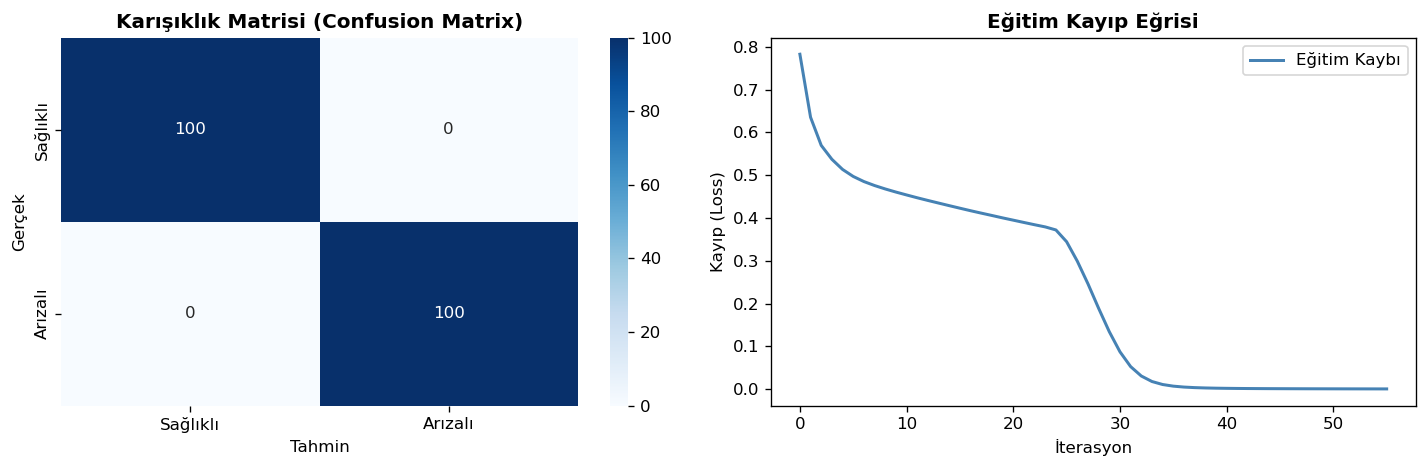

Grafik model_performance.png olarak kaydedildi.


In [8]:
# ── Karışıklık Matrisi + Kayıp Eğrisi ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Karışıklık matrisi
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Sağlıklı', 'Arızalı'],
    yticklabels=['Sağlıklı', 'Arızalı'],
    ax=axes[0]
)
axes[0].set_title('Karışıklık Matrisi (Confusion Matrix)', fontweight='bold')
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')

# Eğitim kayıp eğrisi
axes[1].plot(mlp.loss_curve_, color='steelblue', linewidth=1.8, label='Eğitim Kaybı')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax2 = axes[1].twinx()
    ax2.plot(mlp.validation_scores_, color='tomato', linewidth=1.4,
             linestyle='--', label='Doğrulama Skoru')
    ax2.set_ylabel('Doğrulama Skoru', color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')
axes[1].set_title('Eğitim Kayıp Eğrisi', fontweight='bold')
axes[1].set_xlabel('İterasyon')
axes[1].set_ylabel('Kayıp (Loss)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_performance.png', bbox_inches='tight')
plt.show()
print('Grafik model_performance.png olarak kaydedildi.')

---
## Modül 4 — Görselleştirme ve Dashboard JSON Çıktısı

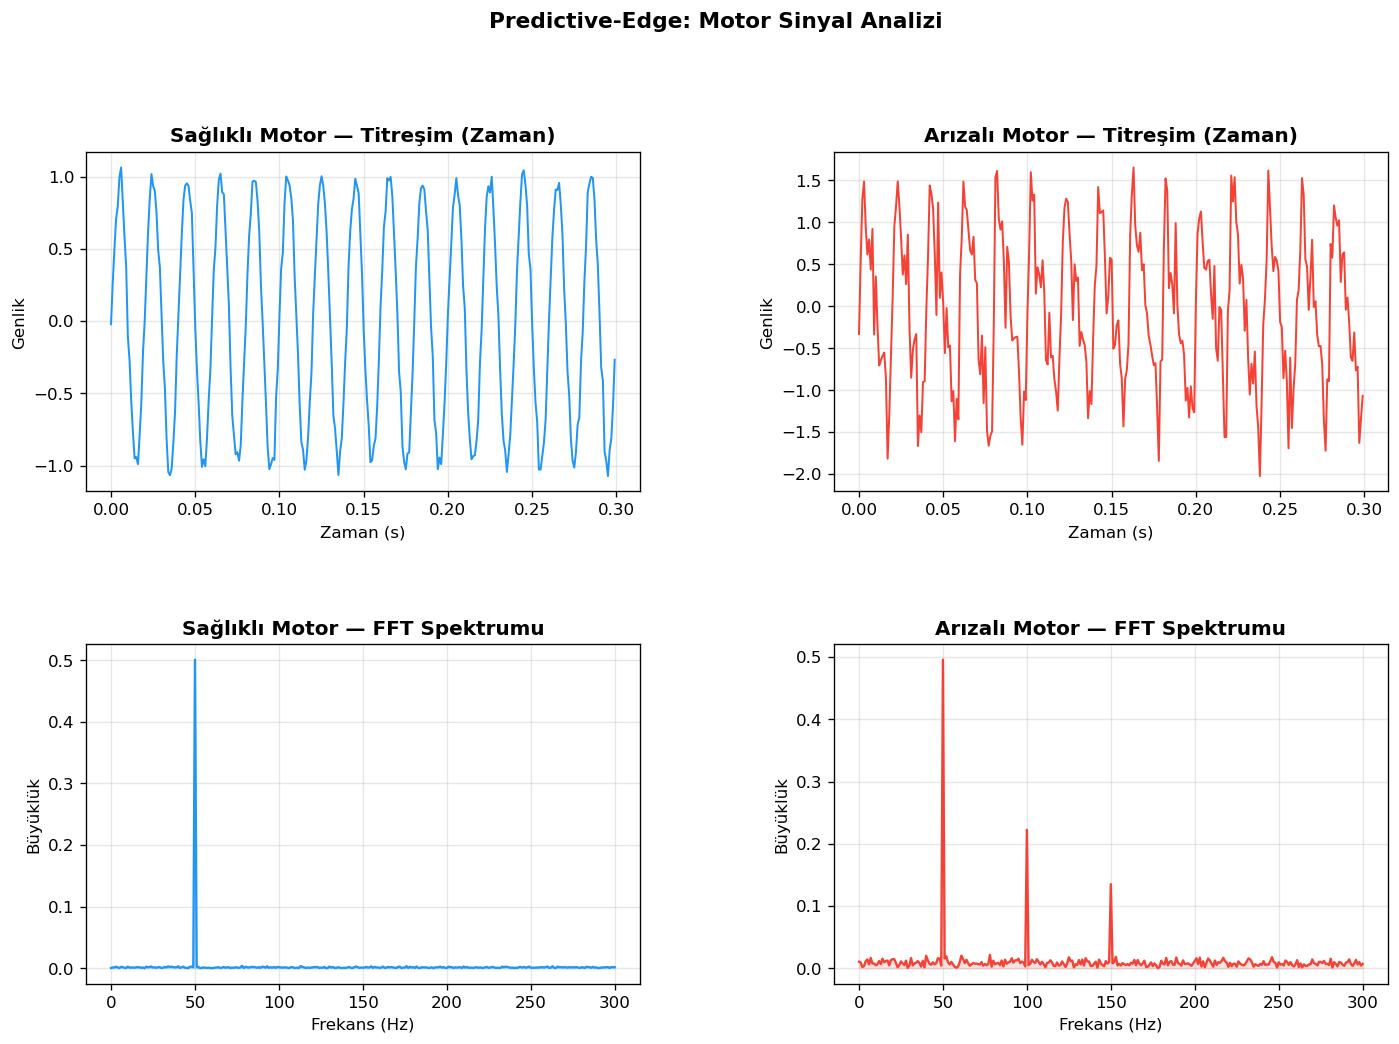

Grafik signal_analysis.png olarak kaydedildi.


In [9]:
# ── Zaman ve frekans domeni sinyalleri ──────────────────────────────────────
healthy_sig = raw_df[raw_df.label == 0].iloc[0]['signal']
faulty_sig  = raw_df[raw_df.label == 1].iloc[0]['signal']

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

colors = {'healthy': '#2196F3', 'faulty': '#F44336'}

# — Zaman domeni: Sağlıklı
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t[:300], healthy_sig[:300], color=colors['healthy'], linewidth=1.2)
ax1.set_title('Sağlıklı Motor — Titreşim (Zaman)', fontweight='bold')
ax1.set_xlabel('Zaman (s)')
ax1.set_ylabel('Genlik')
ax1.grid(alpha=0.3)

# — Zaman domeni: Arızalı
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t[:300], faulty_sig[:300], color=colors['faulty'], linewidth=1.2)
ax2.set_title('Arızalı Motor — Titreşim (Zaman)', fontweight='bold')
ax2.set_xlabel('Zaman (s)')
ax2.set_ylabel('Genlik')
ax2.grid(alpha=0.3)

# — FFT: Sağlıklı
def plot_fft(ax, signal, color, title):
    N = len(signal)
    freqs = spfft.rfftfreq(N, d=1.0 / SAMPLE_RATE)
    mag   = np.abs(spfft.rfft(signal)) / N
    mask  = freqs <= 300
    ax.plot(freqs[mask], mag[mask], color=color, linewidth=1.4)
    ax.fill_between(freqs[mask], mag[mask], alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frekans (Hz)')
    ax.set_ylabel('Büyüklük')
    ax.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
plot_fft(ax3, healthy_sig, colors['healthy'], 'Sağlıklı Motor — FFT Spektrumu')

ax4 = fig.add_subplot(gs[1, 1])
plot_fft(ax4, faulty_sig, colors['faulty'], 'Arızalı Motor — FFT Spektrumu')

plt.suptitle('Predictive-Edge: Motor Sinyal Analizi', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('signal_analysis.png', bbox_inches='tight')
plt.show()
print('Grafik signal_analysis.png olarak kaydedildi.')

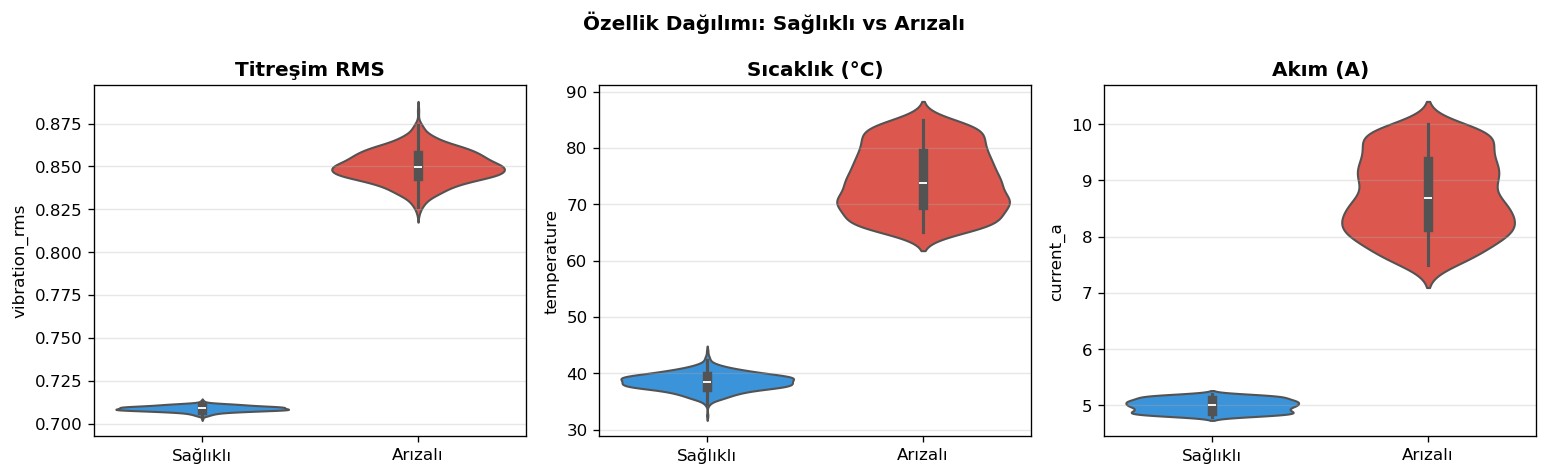

In [10]:
# ── Özellik dağılımı: Violin Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_features = ['vibration_rms', 'temperature', 'current_a']
titles        = ['Titreşim RMS', 'Sıcaklık (°C)', 'Akım (A)']

plot_df = feat_df.copy()
plot_df['durum'] = plot_df['label'].map({0: 'Sağlıklı', 1: 'Arızalı'})

for ax, feat, title in zip(axes, plot_features, titles):
    sns.violinplot(
        data=plot_df, x='durum', y=feat, ax=ax,
        palette={'Sağlıklı': '#2196F3', 'Arızalı': '#F44336'},
        order=['Sağlıklı', 'Arızalı'], inner='box'
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Özellik Dağılımı: Sağlıklı vs Arızalı', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distribution.png', bbox_inches='tight')
plt.show()

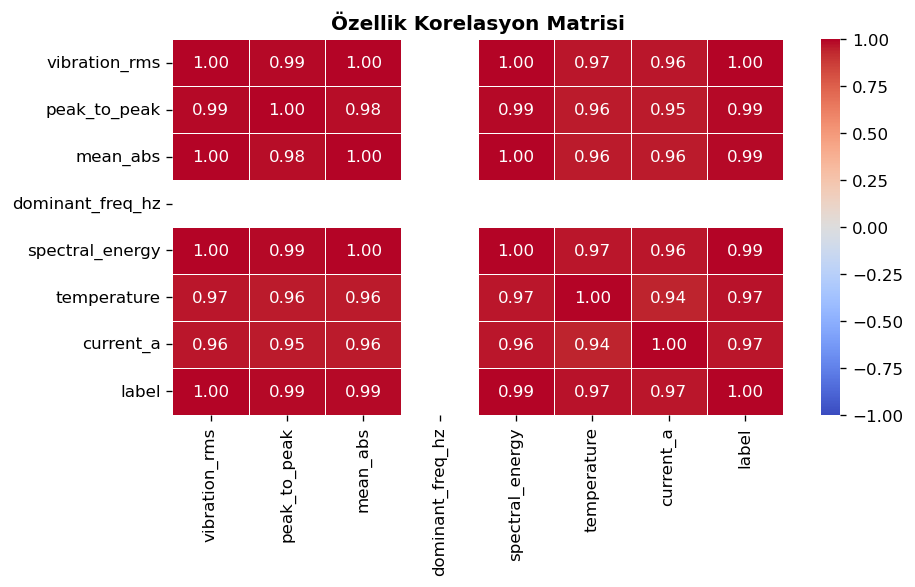

In [11]:
# ── Korelasyon Isı Haritası ──────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
corr = feat_df[FEATURE_COLS + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Özellik Korelasyon Matrisi', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

In [12]:
# ── MERN Dashboard JSON Çıktısı + Alarm Mantığı ─────────────────────────────

def remaining_life_estimate(fault_prob: float) -> dict:
    """
    Arıza olasılığından basit doğrusal kalan ömür tahmini.
    Gerçek uygulamada Weibull / RUL modeli kullanılır.
    """
    if fault_prob < 0.30:
        status  = 'NORMAL'
        rul_hrs = round(np.random.uniform(1800, 2400), 1)
        alarm   = False
    elif fault_prob < 0.65:
        status  = 'UYARI'
        rul_hrs = round(np.random.uniform(400, 1799), 1)
        alarm   = False
    else:
        status  = 'KRİTİK ALARM'
        rul_hrs = round(np.random.uniform(10, 399), 1)
        alarm   = True
    return {'status': status, 'rul_hours': rul_hrs, 'alarm': alarm}


def build_dashboard_payload(sample_idx: int) -> dict:
    """Test setindeki örnek için API-ready JSON yükü oluşturur."""
    feats      = X_test_s[sample_idx]
    raw_feats  = X_test[sample_idx]
    prob       = float(mlp.predict_proba(feats.reshape(1, -1))[0, 1])
    prediction = int(mlp.predict(feats.reshape(1, -1))[0])
    rul_info   = remaining_life_estimate(prob)

    payload = {
        'meta': {
            'project'   : 'Predictive-Edge',
            'version'   : '1.0.0',
            'timestamp' : pd.Timestamp.now().isoformat(),
            'motor_id'  : f'MOTOR-{sample_idx:04d}',
            'unit'      : 'CNC-Spindle'
        },
        'sensor_readings': {
            'vibration_rms'   : round(raw_feats[0], 4),
            'peak_to_peak'    : round(raw_feats[1], 4),
            'mean_abs'        : round(raw_feats[2], 4),
            'dominant_freq_hz': round(raw_feats[3], 2),
            'spectral_energy' : round(raw_feats[4], 6),
            'temperature_c'   : round(raw_feats[5], 2),
            'current_a'       : round(raw_feats[6], 3)
        },
        'prediction': {
            'label'          : prediction,
            'class_name'     : 'Arızalı' if prediction == 1 else 'Sağlıklı',
            'fault_prob_pct' : round(prob * 100, 2),
            'confidence_pct' : round(max(prob, 1 - prob) * 100, 2)
        },
        'maintenance': rul_info
    }
    return payload


# ── İki örnek göster: biri sağlıklı, biri arızalı ───────────────────────────
healthy_idx = int(np.where(y_test == 0)[0][0])
faulty_idx  = int(np.where(y_test == 1)[0][0])

print('\n' + '═' * 55)
print('  ÖRNEK 1 — Sağlıklı Motor')
print('═' * 55)
payload_h = build_dashboard_payload(healthy_idx)
print(json.dumps(payload_h, ensure_ascii=False, indent=2))

print('\n' + '═' * 55)
print('  ÖRNEK 2 — Arızalı Motor')
print('═' * 55)
payload_f = build_dashboard_payload(faulty_idx)
print(json.dumps(payload_f, ensure_ascii=False, indent=2))


═══════════════════════════════════════════════════════
  ÖRNEK 1 — Sağlıklı Motor
═══════════════════════════════════════════════════════
{
  "meta": {
    "project": "Predictive-Edge",
    "version": "1.0.0",
    "timestamp": "2026-05-17T13:27:17.203516",
    "motor_id": "MOTOR-0001",
    "unit": "CNC-Spindle"
  },
  "sensor_readings": {
    "vibration_rms": 0.7102,
    "peak_to_peak": 2.2258,
    "mean_abs": 0.6356,
    "dominant_freq_hz": 50.0,
    "spectral_energy": 0.252215,
    "temperature_c": 39.01,
    "current_a": 5.105
  },
  "prediction": {
    "label": 0,
    "class_name": "Sağlıklı",
    "fault_prob_pct": 0.16,
    "confidence_pct": 99.84
  },
  "maintenance": {
    "status": "NORMAL",
    "rul_hours": 1981.2,
    "alarm": false
  }
}

═══════════════════════════════════════════════════════
  ÖRNEK 2 — Arızalı Motor
═══════════════════════════════════════════════════════
{
  "meta": {
    "project": "Predictive-Edge",
    "version": "1.0.0",
    "timestamp": "2026-05-17

In [13]:
# ── Toplu JSON dışa aktarım (MERN API entegrasyonu için) ─────────────────────
all_payloads = [build_dashboard_payload(i) for i in range(len(X_test))]

with open('dashboard_output.json', 'w', encoding='utf-8') as f:
    json.dump(all_payloads, f, ensure_ascii=False, indent=2)

print(f'{len(all_payloads)} örneğin API yükü dashboard_output.json dosyasına yazıldı.')

# Alarm özeti
alarm_count   = sum(1 for p in all_payloads if p['maintenance']['alarm'])
warning_count = sum(1 for p in all_payloads if p['maintenance']['status'] == 'UYARI')
print(f'\nAlarm Özeti:')
print(f'  KRİTİK ALARM : {alarm_count} motor')
print(f'  UYARI        : {warning_count} motor')
print(f'  NORMAL       : {len(all_payloads) - alarm_count - warning_count} motor')

200 örneğin API yükü dashboard_output.json dosyasına yazıldı.

Alarm Özeti:
  KRİTİK ALARM : 100 motor
  UYARI        : 0 motor
  NORMAL       : 100 motor


In [14]:
# ── Sistem Özeti ─────────────────────────────────────────────────────────────
print('╔' + '═' * 50 + '╗')
print('║        PREDICTIVE-EDGE — SİSTEM ÖZETİ          ║')
print('╠' + '═' * 50 + '╣')
print(f'║  Toplam Örnek        : {len(raw_df):<27}║')
print(f'║  Özellik Sayısı      : {len(FEATURE_COLS):<27}║')
print(f'║  MLP Mimarisi        : {"7 → 16 → 8 → 1":<27}║')
print(f'║  Eğitim İterasyonu   : {mlp.n_iter_:<27}║')
print(f'║  Test Doğruluğu      : {acc*100:.2f}%{"":<22}║')
print(f'║  F1-Skoru            : {f1:.4f}{"":<23}║')
print(f'║  Arıza Hassasiyeti   : {prec:.4f}{"":<23}║')
print(f'║  Arıza Geri Çağırma  : {rec:.4f}{"":<23}║')
print('╚' + '═' * 50 + '╝')
print()
print('Çıktı dosyaları:')
print('  📊 signal_analysis.png      — Sinyal grafikleri')
print('  📈 model_performance.png    — Karışıklık matrisi + kayıp')
print('  🎻 feature_distribution.png — Özellik dağılımları')
print('  🔥 correlation_matrix.png   — Korelasyon ısı haritası')
print('  🗂️  dashboard_output.json    — MERN API yükü')

╔══════════════════════════════════════════════════╗
║        PREDICTIVE-EDGE — SİSTEM ÖZETİ          ║
╠══════════════════════════════════════════════════╣
║  Toplam Örnek        : 1000                       ║
║  Özellik Sayısı      : 7                          ║
║  MLP Mimarisi        : 7 → 16 → 8 → 1             ║
║  Eğitim İterasyonu   : 56                         ║
║  Test Doğruluğu      : 100.00%                      ║
║  F1-Skoru            : 1.0000                       ║
║  Arıza Hassasiyeti   : 1.0000                       ║
║  Arıza Geri Çağırma  : 1.0000                       ║
╚══════════════════════════════════════════════════╝

Çıktı dosyaları:
  📊 signal_analysis.png      — Sinyal grafikleri
  📈 model_performance.png    — Karışıklık matrisi + kayıp
  🎻 feature_distribution.png — Özellik dağılımları
  🔥 correlation_matrix.png   — Korelasyon ısı haritası
  🗂️  dashboard_output.json    — MERN API yükü
